In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

from src.graphs import StaticGraph, IntersectingEdgesGraph
from src.bwt import HardWeldedTree

Edges: {('0011', '1110'), ('0100', '1001'), ('0100', '0010'), ('1110', '0100'), ('0000', '1000'), ('1000', '0011'), ('1001', '0011'), ('0000', '0100'), ('0011', '1001'), ('0100', '0100'), ('0011', '0010'), ('1110', '0011'), ('1001', '0001'), ('0100', '1110'), ('1110', '1001'), ('1001', '0100'), ('0011', '0100'), ('1110', '0001'), ('0010', '0011'), ('0100', '0011'), ('1000', '1110'), ('0001', '0011'), ('1001', '1110')}


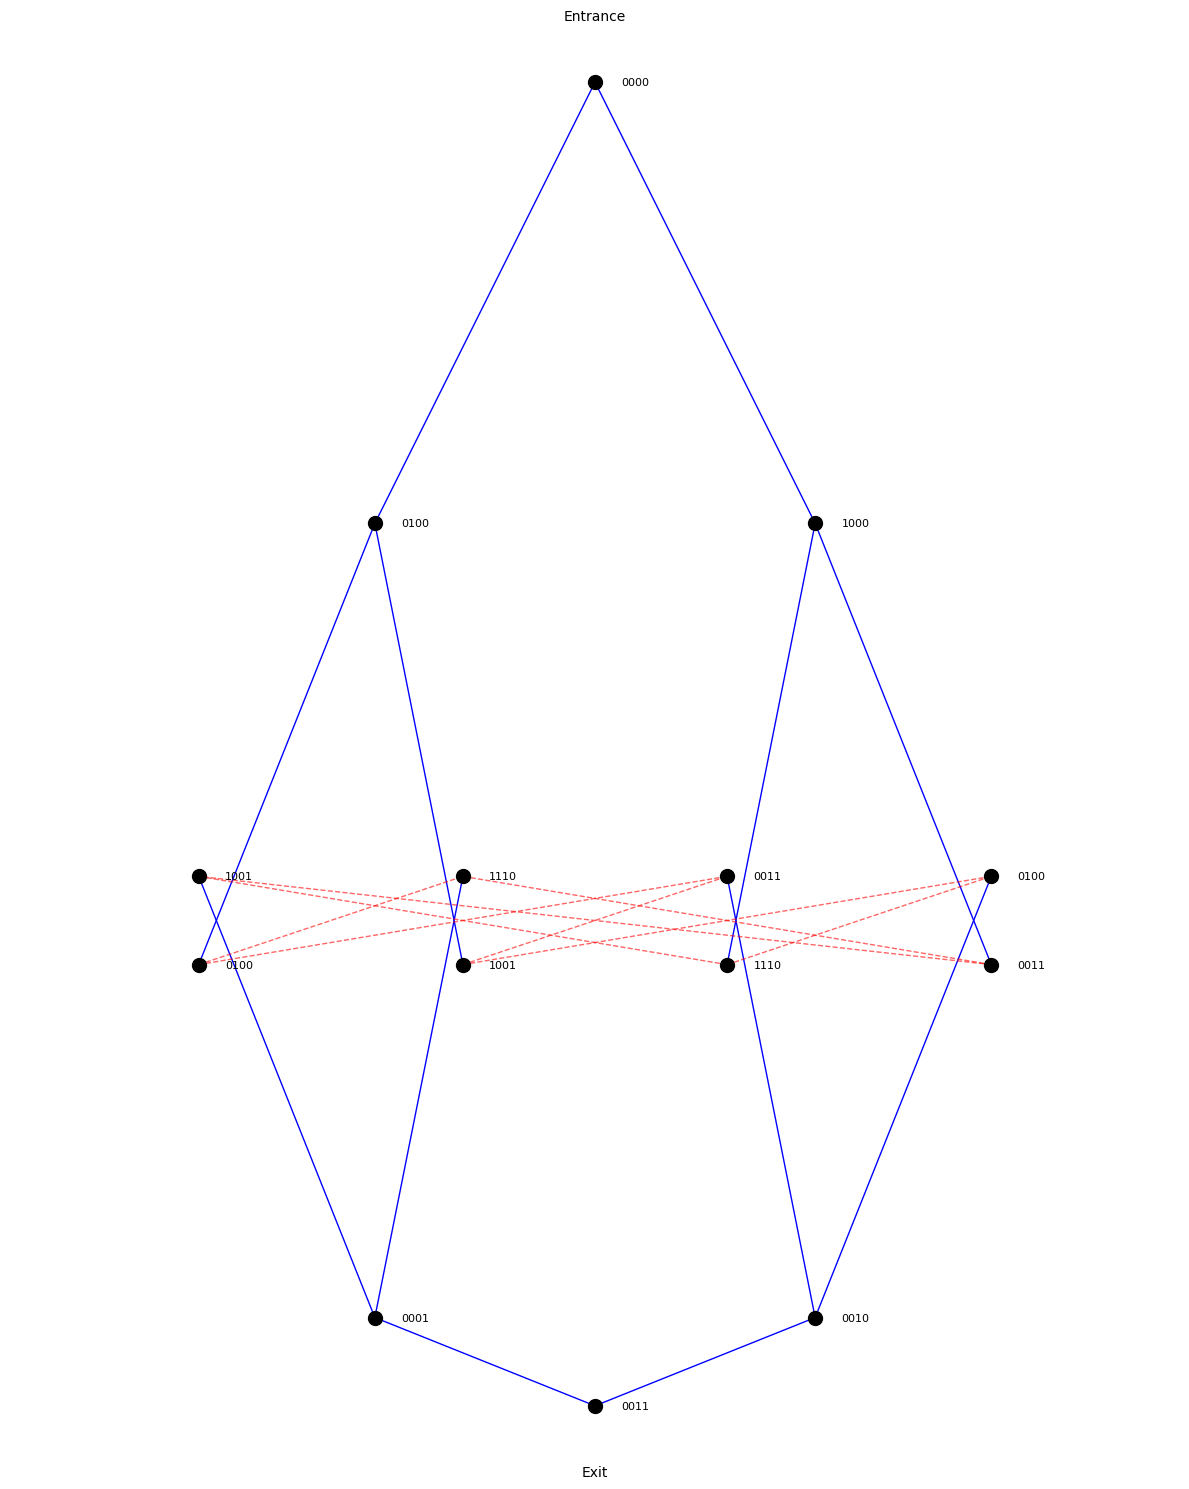

In [2]:
maze = HardWeldedTree(2)  # Now works for any height
edges = maze.get_edges()
print("Edges:", edges)
fig = maze.draw()
plt.show()

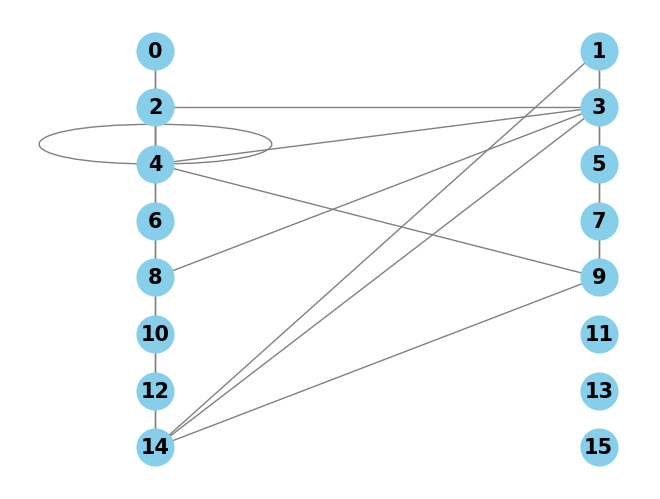

None

In [3]:
# Create the welded binary maze
maze = HardWeldedTree(2)  # For a 2-level maze

# Get the edges in the required format
edges = maze.get_edges()

# Use your existing graph analysis
G_tree = StaticGraph(edges)
display(G_tree.draw())

Edges: {('0011', '1110'), ('0100', '1001'), ('0000', '1000')}


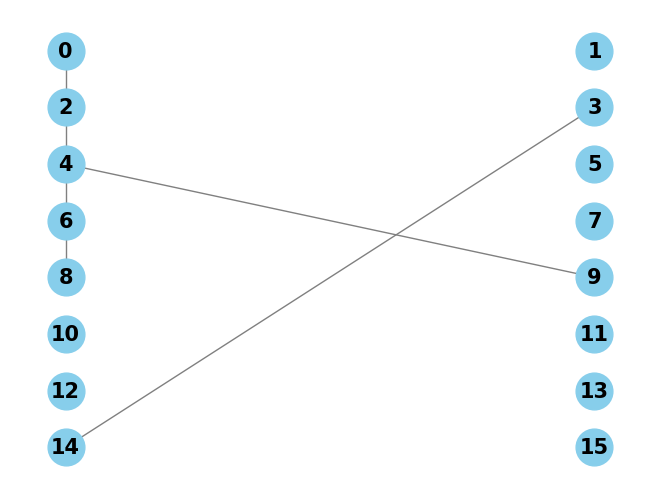

None

Simplified circuit: 


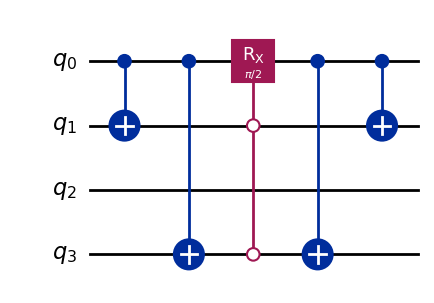

Edges: {('1000', '0011'), ('0100', '0010'), ('1001', '0001')}


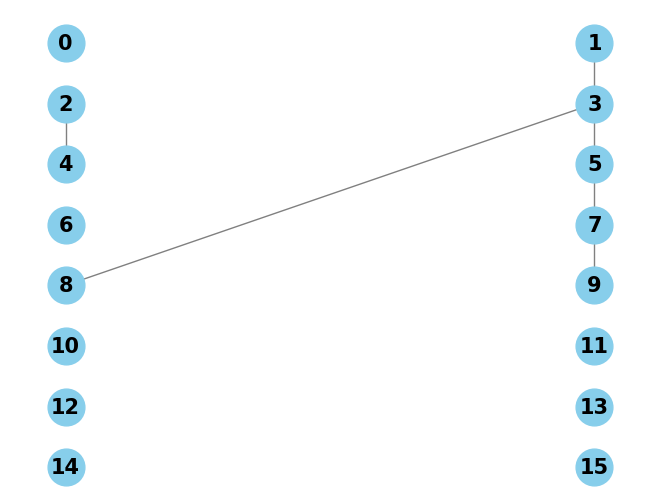

None

Simplified circuit: 


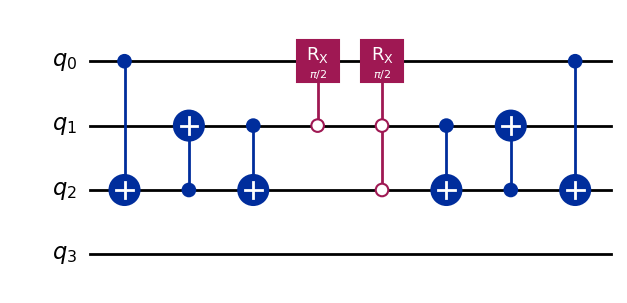

Edges: {('1001', '0011'), ('1110', '0100')}


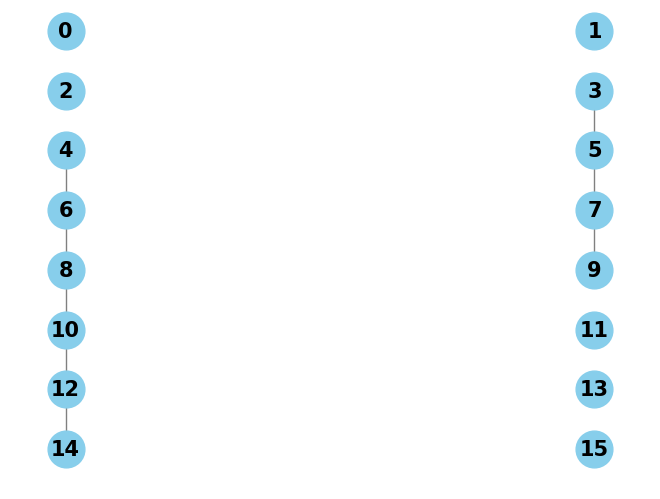

None

Simplified circuit: 


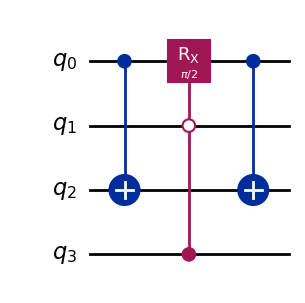

Edges: {('0000', '0100'), ('0011', '1001'), ('1110', '0001')}


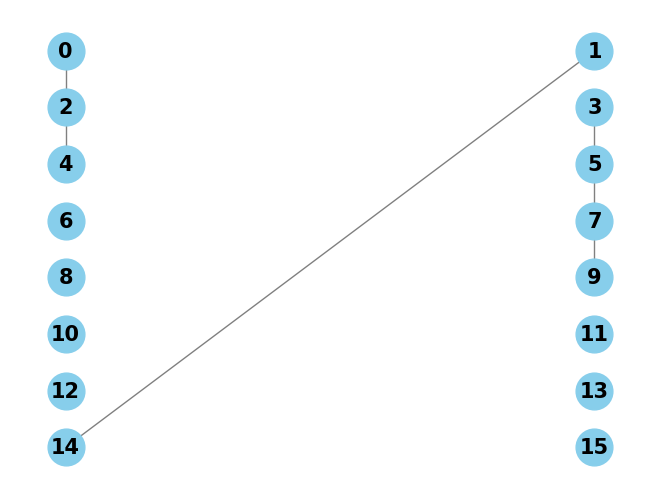

None

Simplified circuit: 


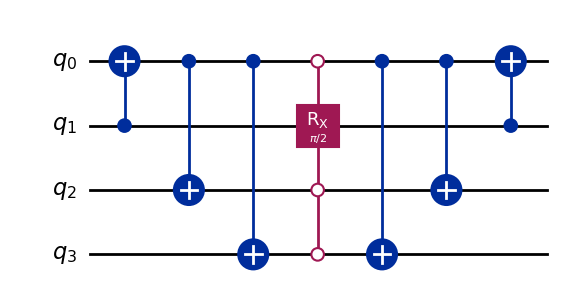

Edges: {('0011', '0010'), ('1110', '1001'), ('0100', '0100')}


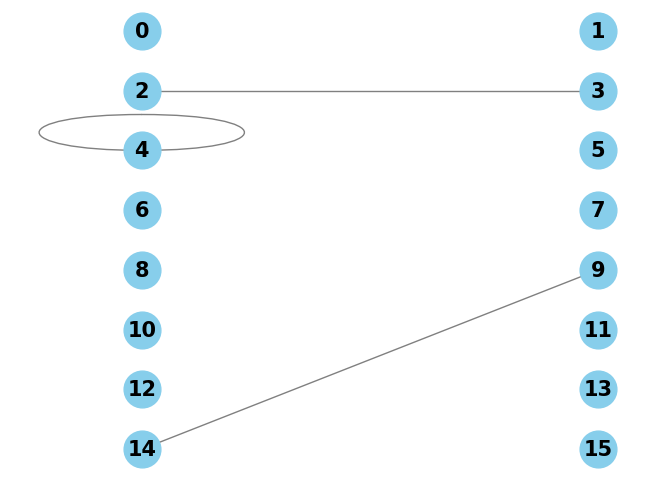

None

Simplified circuit: 


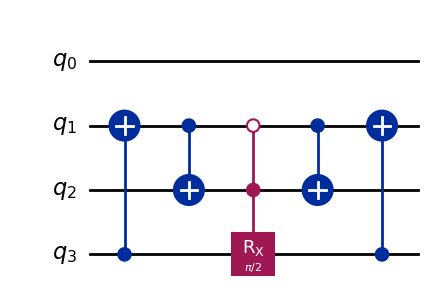

Edges: {('1110', '0011'), ('1001', '0100')}


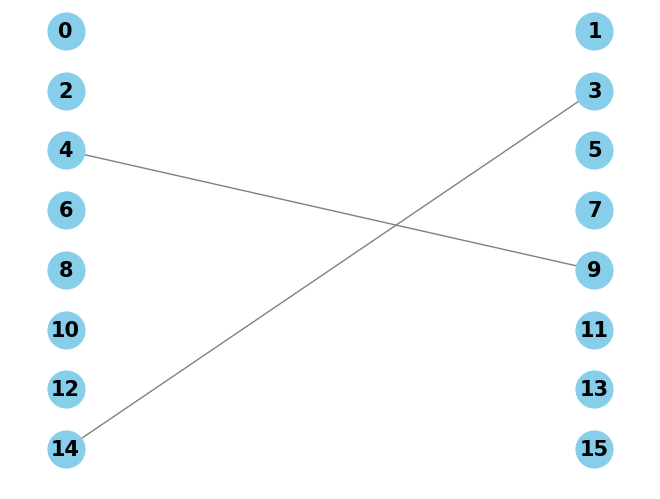

None

Simplified circuit: 


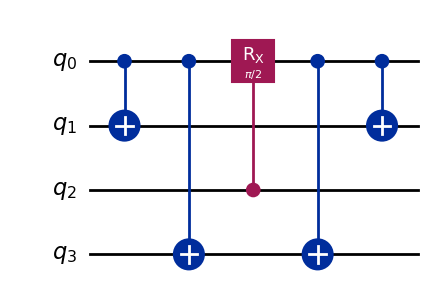

Edges: {('0100', '1110'), ('0010', '0011')}


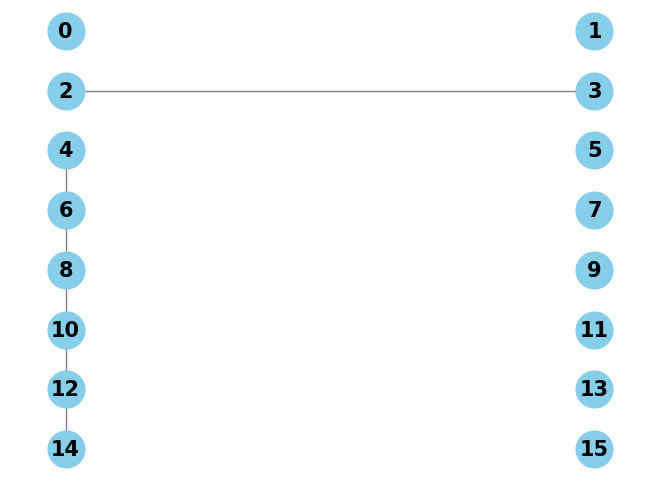

None

Simplified circuit: 


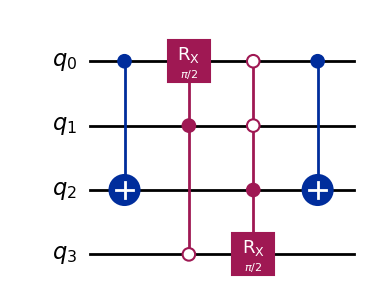

Edges: {('0011', '0100'), ('1000', '1110')}


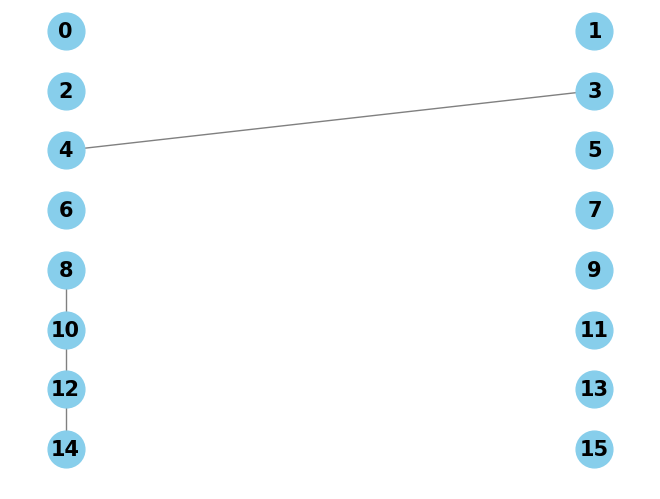

None

Simplified circuit: 


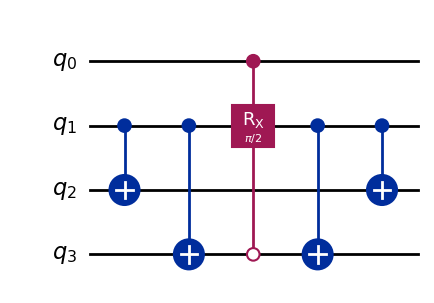

Edges: {('0100', '0011'), ('1001', '1110')}


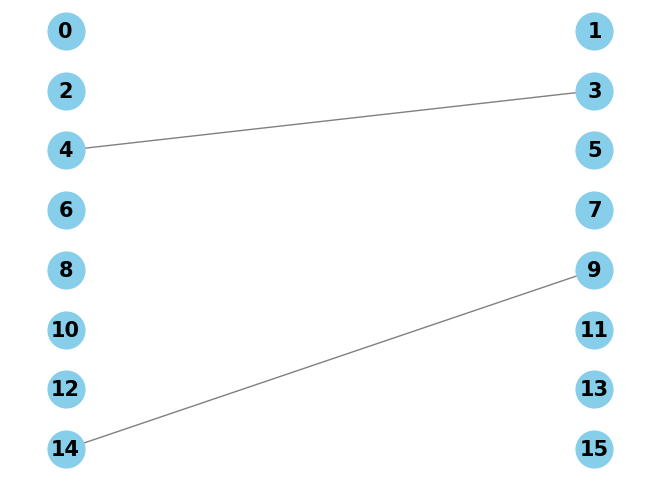

None

Simplified circuit: 


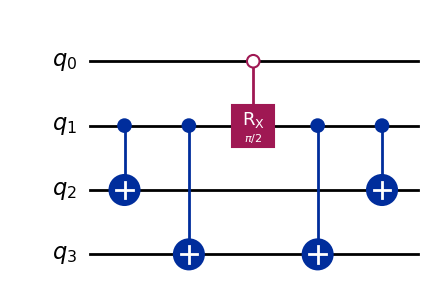

Edges: {('0001', '0011')}


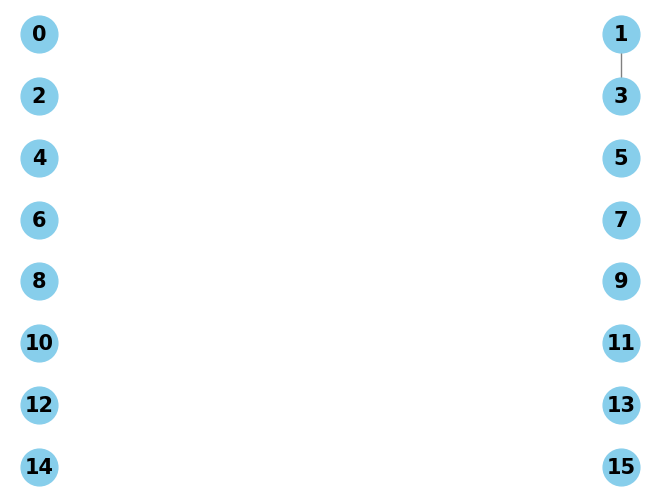

None

Simplified circuit: 


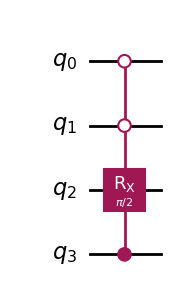

In [4]:

G = IntersectingEdgesGraph(edges)

big_qc = QuantumCircuit(G_tree.n_qubits)

for g in G.subgraphs:
    print(f'Edges: {g.edges}')
    display(g.draw())
    # print('Unsimplified circuit: ')
    # qc = g.get_qc(simplified=False)
    # display(qc.draw('mpl'))
    print('Simplified circuit: ')
    qc = g.get_qc(simplified=True)
    big_qc = big_qc.compose(qc)
    display(qc.draw('mpl'))
    

Full Circuit


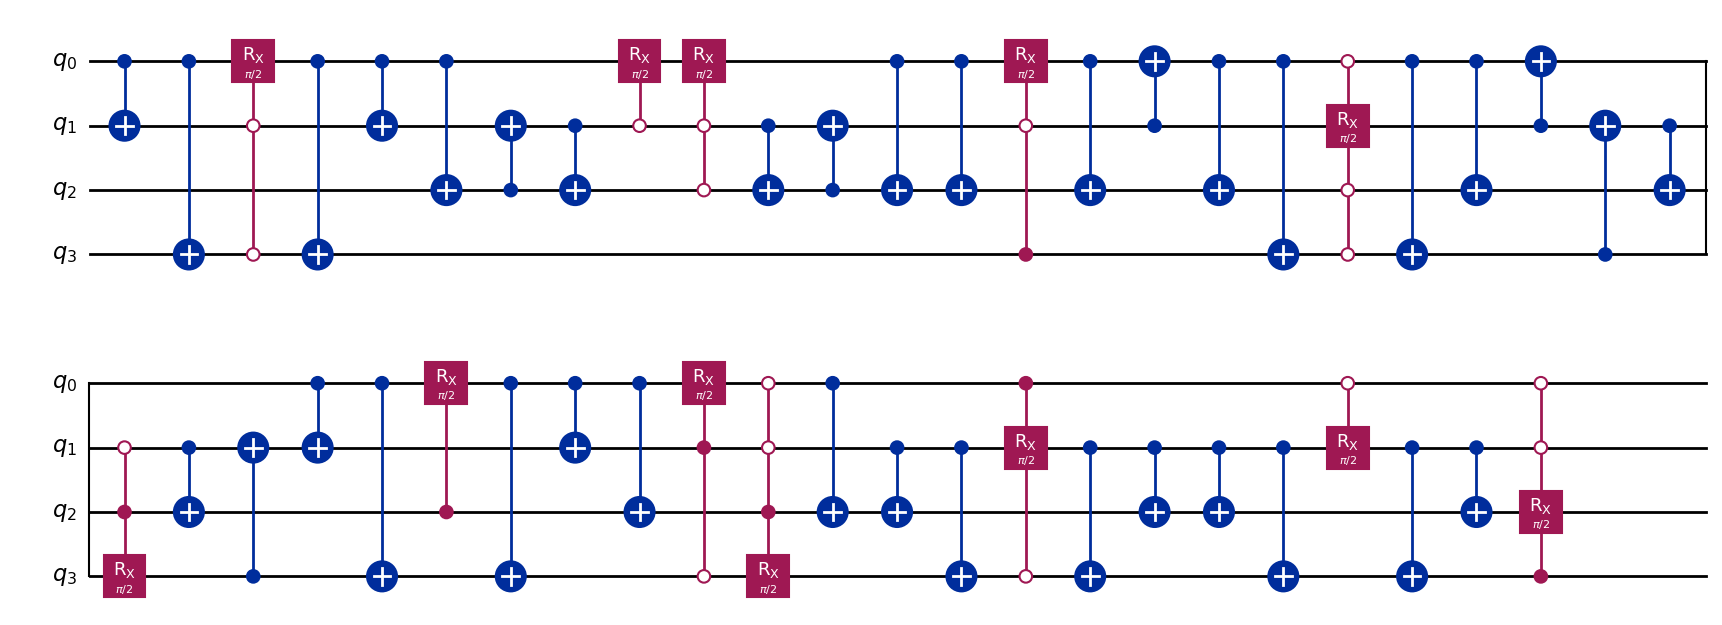

In [5]:
print('Full Circuit')
big_qc.draw('mpl')

In [6]:
from qiskit import transpile

transpiled_qc = transpile(
    big_qc,
    basis_gates=["cx", "u3"],
    optimization_level=3
)

counts = transpiled_qc.count_ops()
print(f'Number of CX gates: {counts['cx']}')
print(f'Number of U3 gates: {counts['u3']}')

Number of CX gates: 139
Number of U3 gates: 127
